# Customer Churn - Exploratory Data Analysis

**Goal**: Understand the drivers of customer churn and identify patterns that may help build predictive models and customer segments.

**Dataset**: Telco Customer Churn (Kaggle)
- Observations: 7043 customers
- Target variable: Churn

These insights will later support:
- Customer segmentation
- Churn prediction models

## Load Dataset

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_data, plot_feature, plot_vs

df = load_data('../data/raw/telco_customer_churn.csv')

### Dataset Overview

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


This dataset has 7043 entries (customers) and 21 columns, where 17 are categorical variables and 4 are numeric variables.
Looking into the data type from each column, it is possible to see that TotalCharges column is a str when it should be numeric. That way, it is important to convert it to a numeric value:

In [4]:
df.TotalCharges = pd.to_numeric(df.TotalCharges, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Another important step is to verify if there are NA values:

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

TotalChages has 11 missing values, therefore it's important to establish a method to deal with this, when processing the data.

### Churn Variable - Target Variable Analysis

Now that all the independent variables are analysed. Let's focus on the dependent variable (Churn Variable).

In [7]:
df['Churn'].value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

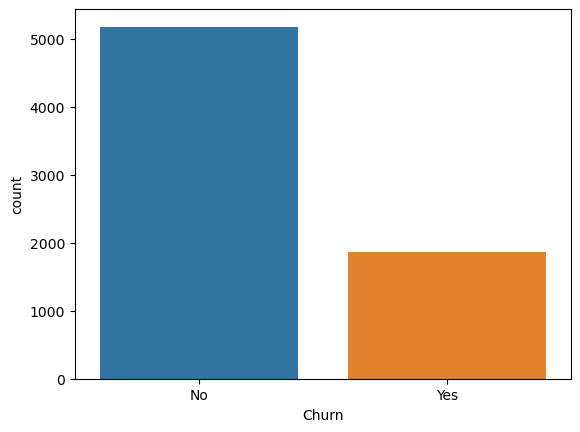

In [8]:
sns.countplot(x="Churn", data=df)

In this dataset there are 5174 customers that didin't stop the telecom services and 1869 that decided to stop this service. Therefore, about one quarter of customers churn (26.5%).

### Numeric Variables Analysis

The main numeric variables are:
- **Tenure** - number of months the customer has stayed with the company
- **MonthlyCharges** - amount of charge for service on monthly bases
- **TotalCharges** - cumulative charges for service during subscription (tenure) period

#### Tenure Distribuiton

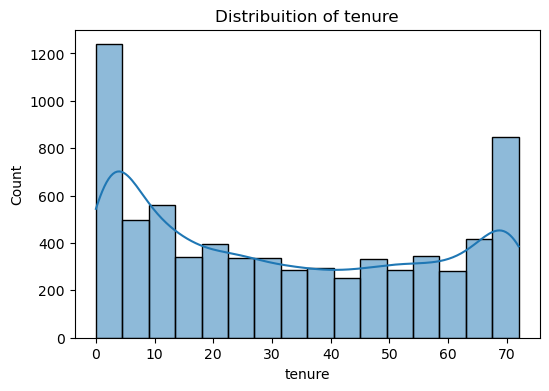

In [9]:
plot_feature(df, 'tenure')

The tenure distribution appears bimodal, with a **high concentration** of customers at very low tenure (around **0–5 months**) and another noticeable cluster at **long tenure** (around **65–72 months**). This pattern suggests that many customers are either **new subscribers** who recently joined or **long-term customers** who have stayed with the company for several years. The lower number of customers in the middle tenure ranges indicates fewer customers with moderate lengths of service. 

This distribution is important for churn analysis because **new customers are typically more likely to churn**, while long-tenure customers tend to be more loyal and stable, making tenure a strong predictor when building churn prediction models.

#### Monthly Charges Distribution

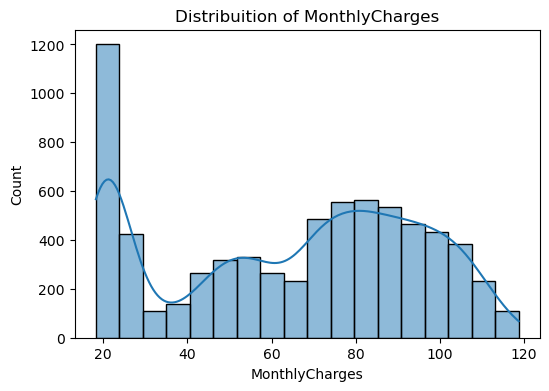

In [10]:
plot_feature(df, 'MonthlyCharges')

In the histogram it is possible to see that the distribution is not perfectly normal and appears multi-modal, with noticeable peaks around the lower and higher charge ranges. A large concentration of customers falls within the **$20–30 range**, which likely represents users with **basic or limited service plans**. Another significant cluster appears between **$70 and $100**, suggesting many customers subscribe to **more comprehensive packages that include additional services** such as internet, streaming, or bundled features. 
Adittional, the relatively smaller number of customers in the mid-range (around **$30–40**) indicates **fewer pricing plans or fewer customers selecting those options**. 

Overall, the pattern suggests that the company offers **distinct service tiers**, and customers tend to cluster around specific pricing levels rather than being evenly distributed across all charges. This type of distribution can be useful when analyzing customer behavior and may help identify how pricing tiers relate to customer retention or churn patterns.

#### Total Charges Distribution

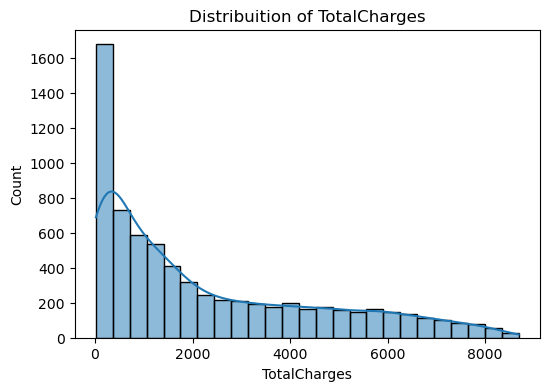

In [11]:
plot_feature(df, 'TotalCharges')

The distribution of TotalCharges is positively skewed, with the **majority of customers having relatively low total charges** and a **smaller number of customers accumulating very high charges**. This pattern indicates that many customers are either **new or have shorter tenures**, resulting in lower cumulative spending, while a smaller group of long-term customers generates significantly higher total charges over time. The long right tail of the distribution reflects these high-value, long-tenure customers. 
Overall, the distribution suggests that customer tenure and cumulative spending are unevenly distributed across the customer base, which may have implications for churn behavior and customer retention analysis.

### Categorical Variables Analysis
This are the variables that are going to be analised:
- **Contract Type** - type of contract according to duration (Month-to-month, One year, Two year)
- **Internet Service** - customer’s internet service provider (DSL, Fiber optic, No)

#### Contract Type 

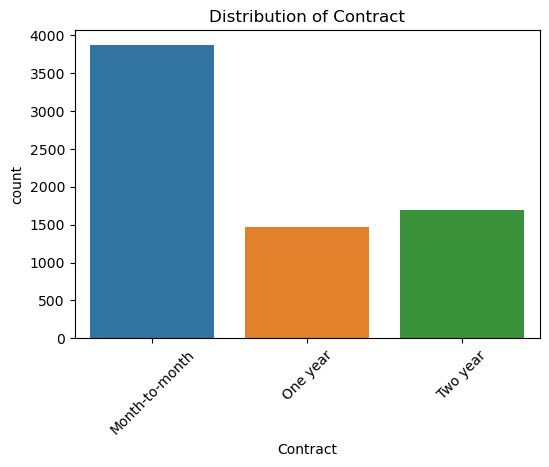

In [12]:
plot_feature(df, 'Contract')

The distribution of contract types shows that **month-to-month contracts are the most common**, representing the largest portion of customers. In contrast, one-year and two-year contracts have significantly fewer customers, with the two-year contracts slightly more common than one-year contracts. This suggests that most customers prefer **flexible short-term agreements** rather than long-term commitments. From a churn analysis perspective, this pattern is important because customers with month-to-month contracts typically have a higher likelihood of churn, as they are not locked into long-term agreements.


#### Internet Service

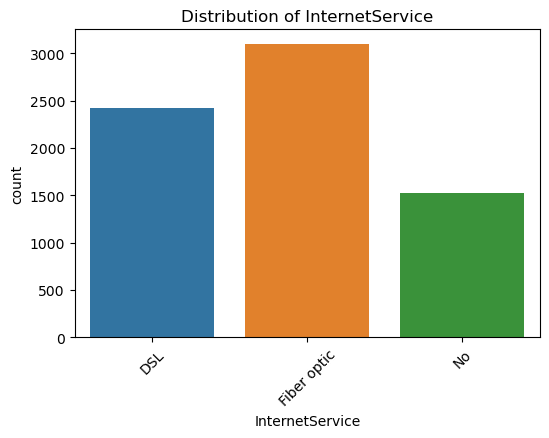

In [13]:
plot_feature(df, 'InternetService')

The distribution of internet service types indicates that **fiber optic is the most widely used service**, followed by DSL, while a smaller portion of customers do not subscribe to internet service. This suggests that high-speed fiber connections are the dominant offering among customers, reflecting a demand for faster internet services. The presence of a notable group without internet service also indicates that the dataset includes customers who may only subscribe to other telecom services. These differences in service types may influence customer satisfaction, pricing, and churn behavior, making internet service type a relevant variable for churn prediction.


#### Payment Method

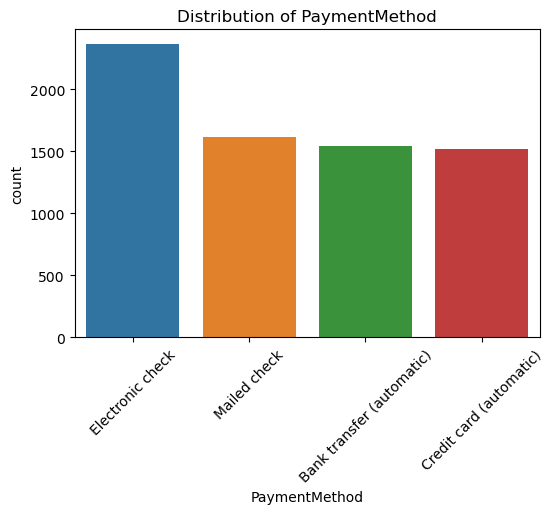

In [19]:
plot_feature(df, 'PaymentMethod')

This graph shows that **eletronic check is the most common payment method** among customers. The other three types of payment show a similar distribution. The two automatic payment methods could potential show the customer interest in having a long term service. However as eletronic check is the most used, payment method can be a good predictor to churn.

### Variables VS Churn Analysis

Looking into the prior results, it is important to test the relationship between Churn Variable with the independent variables in this dataset to see if there are some important correlations between them, such as:
- Contract Type VS Churn
- Tenure VS Churn
- Montlhy Charges VS Churn
- Internet Service VS Churn

#### Contract Type VS Churn

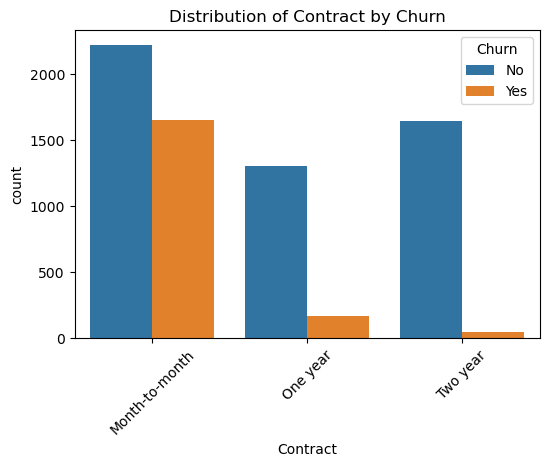

In [14]:
plot_vs(df, 'Contract')

The relationship between contract type and churn shows a clear pattern. **Customers with month-to-month contracts exhibit the highest number of churn cases**, indicating that those without long-term commitments are more likely to leave the service. In contrast, **customers with one-year and especially two-year contracts show significantly lower churn counts**, suggesting that longer contractual commitments contribute to greater customer retention. This result highlights contract length as an important factor influencing customer churn behavior.

#### Tenure VS Churn

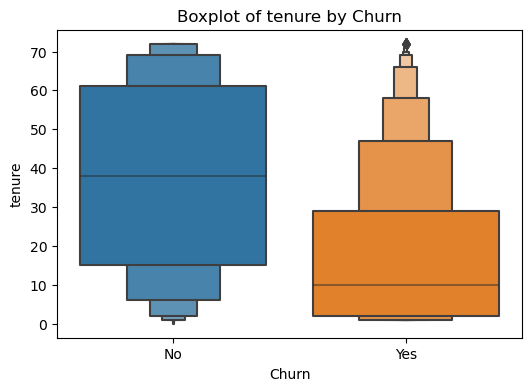

In [15]:
plot_vs(df, 'tenure')

The boxplot comparing tenure by churn status shows a clear difference between the two groups. **Customers who did not churn generally have much longer tenures**, with a higher median and a wider distribution toward larger values. In contrast, **customers who churned tend to have shorter tenures**, with most values concentrated at the lower end of the scale. This suggests that customers are more likely to leave during the early stages of their relationship with the company, while long‑term customers tend to remain loyal.

#### Monthly Charges VS Churn

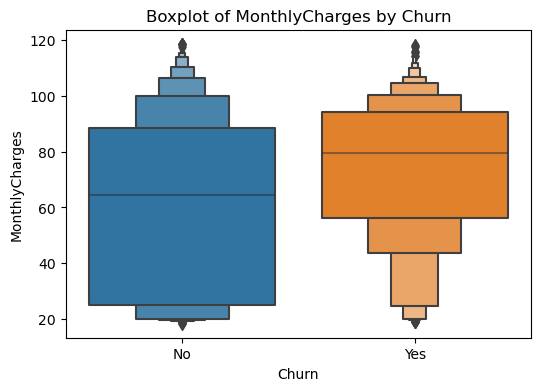

In [16]:
plot_vs(df, 'MonthlyCharges')

The boxplot of monthly charges by churn status indicates that **customers who churned tend to have higher monthly charges on average compared to those who stayed**. The median monthly charge for churned customers is noticeably higher, and the distribution is shifted toward larger values. This pattern suggests that higher service costs may be associated with an increased likelihood of churn, possibly because customers perceive the service as too expensive relative to its value.

#### Internet Service VS Churn

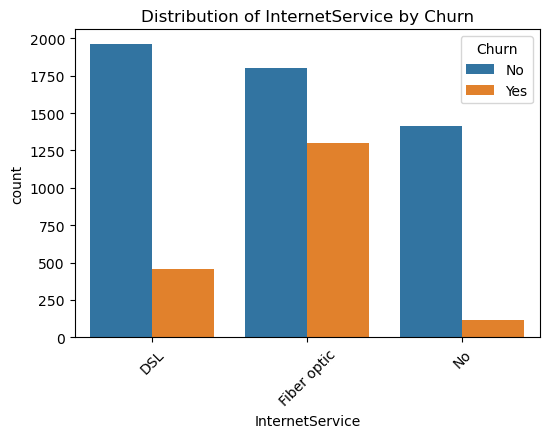

In [17]:
plot_vs(df, 'InternetService')

The analysis of internet service type and churn reveals notable differences among service categories. **Customers using fiber optic internet show the highest number of churn cases**, despite also having a large customer base. Meanwhile, **DSL users experience relatively lower churn**, and customers without internet service exhibit the lowest churn levels overall. This pattern suggests that the type of internet service may influence customer satisfaction or pricing perceptions, making it a potentially important variable in predicting churn.


#### PaymentMethod vs Churn

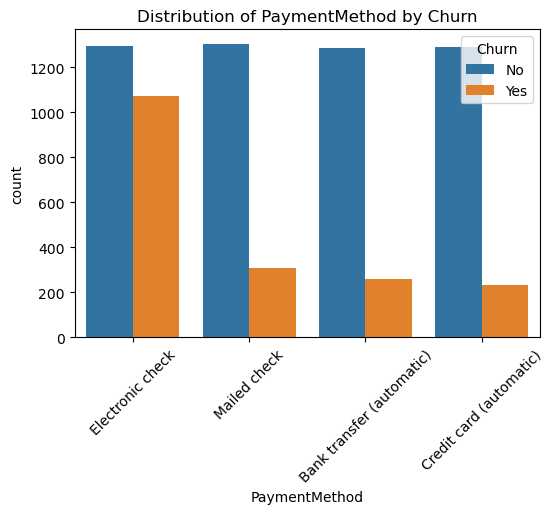

In [20]:
plot_vs(df, 'PaymentMethod', 'Churn')

The analysis of the payment method and churn reveals some differences among payment methods. Customers that prefer **electronic check are more likely to churn**. Regarding the other 3 methods the probability to churn is similar. The fact that most customers that use eletronic check have a higher probability to churn makes this variable an important one in predicting churn.


### Correlation Analysis
A correlation analysis is important in order to detect some correlation between the numeric variables:

<Axes: >

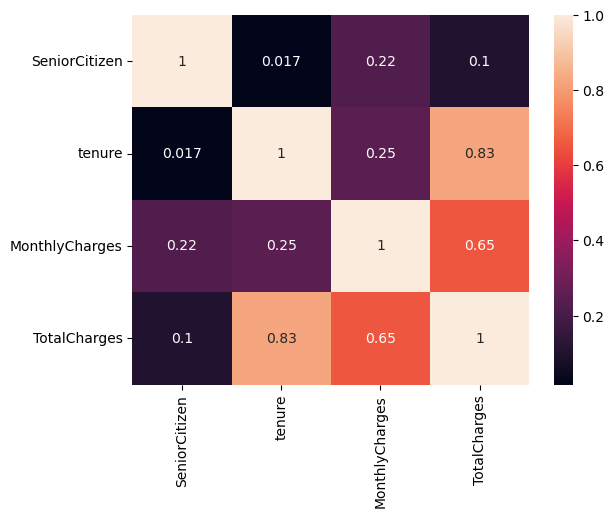

In [18]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

For this correlation heatmap, a few key relationships stand out:
- **Tenure and Total Charges** (0.83) show a very strong positive correlation, meaning customers who stay longer naturally accumulate higher total charges. This is expected because total charges increase over time as customers continue paying for the service.
- **Monthly Charges and Total Charges** (0.65) have a moderate to strong positive correlation, indicating that customers who pay higher monthly fees tend to accumulate higher overall charges.
- **Monthly Charges and Tenure** (0.25) show only a weak relationship, suggesting that how long a customer stays is not strongly related to how much they pay monthly.
- Senior Citizen has very weak correlations with the other variables, meaning age category does not strongly relate to tenure, monthly charges, or total charges in this dataset.

Main insight: the strongest relationship is between tenure and total charges, which makes sense because total spending grows as customers remain subscribed for longer periods. This also suggests that these variables may carry similar information in predictive models, so multicollinearity should be considered during modeling.

### Sumarizing
- Month-to-month contracts show the highest churn rate.
- Customers with short tenure churn more frequently.
- Fiber optic internet users have higher churn.
- Higher monthly charges appear correlated with churn.
- Customers without additional support services churn more.

## Next Steps
In order to **develop a machine learning model** that predicts whether a customer is likely to churn, this are the next steps:
1. Data cleaning
2. Feature engineering
3. Customer segmentation using clustering
4. Churn prediction using machine learning models